In [1]:
import os
from pathlib import Path
import torch 
import numpy as np

from ml.inference import load_checkpoint

## On charge le modèle MAEv1 après premier run de préentrainement
base = Path.cwd()

ckpt_dir = Path(os.path.join(base, '..', '..', 'outputs', 'ml', 'pretrain', '2026-08-05_13-36-04', 'checkpoints', 'best.pt'))

device = torch.device("cpu")
pretrained_model, cfg, mean, scale = load_checkpoint(ckpt_dir, device)
print(pretrained_model)


TimeSeriesMAE(
  (patch_embedding): PatchEmbedding(
    (proj): Conv1d(11, 64, kernel_size=(12,), stride=(12,))
  )
  (encoder_pos_embedding): LearnedPositionalEmbedding(
    (PE): Embedding(8, 64)
  )
  (decoder_pos_embedding): LearnedPositionalEmbedding(
    (PE): Embedding(9, 32)
  )
  (encoder_blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (MSA): MultiHeadSelfAttention(
        (query_matrix): Linear(in_features=64, out_features=64, bias=True)
        (key_matrix): Linear(in_features=64, out_features=64, bias=True)
        (value_matrix): Linear(in_features=64, out_features=64, bias=True)
        (output_proj): Linear(in_features=64, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (MLP): MLP(
        (dense1): Linear(in_features=64, out_features=256, bias=True)
        (d

In [2]:
## on charge les poids de l'encoder du modèle préentrainé sur un backbone avec les mêmes paramètres (cf MAEv1.yaml pour l'archi de l'encoder)
from ml.model import VanillaViT

encoder_sd = pretrained_model.encoder_state_dict() ## donne directement les poids de l'encodeur avec les bons mapping


backbone = VanillaViT(
    n_features = 11, 
    n_epochs= 96, 
    patch_size=12, 
    embed_dim=64,
    n_attn_heads=4,
    n_blocks=4,
    expansion_factor=4,
    dropout_rate=0.1
)
missing, unexpected = backbone.load_state_dict(encoder_sd, strict=False) # les poids sont bien chargés. 



In [3]:
from ml.datahandler import load_spacetrack_objects, build_features, diff_cols_spacetrack

data_dir = Path(os.path.join(base, '..' , '..', 'data', 'raw', 'spacetrack'))
objects = load_spacetrack_objects(data_dir)

per_obj = {}
for key, df in objects.items(): 
    features, feature_cols = build_features(df, spacetrack=True)
    X = (features[feature_cols].to_numpy(np.float32) - mean) / scale
    per_obj[key] = X

backbone.eval()
backbone.to(device)

window_size = 96 
batch_size = 256

out = {}
for norad, X in per_obj.items():
    if len(X) < window_size : 
        continue 
    windows = np.lib.stride_tricks.sliding_window_view(X, window_size, axis=0) # (L,F,W)

    cls_representations = []

    for i in range(0, len(windows), batch_size): 
        x = torch.from_numpy(np.ascontiguousarray(windows[i:i+batch_size])).float().to(device)

        with torch.no_grad(): 
            representation = backbone(x)
        cls_representations.append(representation[:,0,:].cpu().numpy()) ## on ne stocke que le cls token !

    if cls_representations:
        out[norad] = np.concatenate(cls_representations, axis=0).mean(axis=0) 


In [69]:
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## une représentation par objet : token CLS (indice 0) moyenné sur toutes les fenêtres
norad_ids = list(out.keys())
X_obj = np.stack([out[n] for n in norad_ids])
X_scaled = StandardScaler().fit_transform(X_obj)

clusterer = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=15)

labels = clusterer.fit_predict(X_scaled)

n_clusters = len(set(labels))



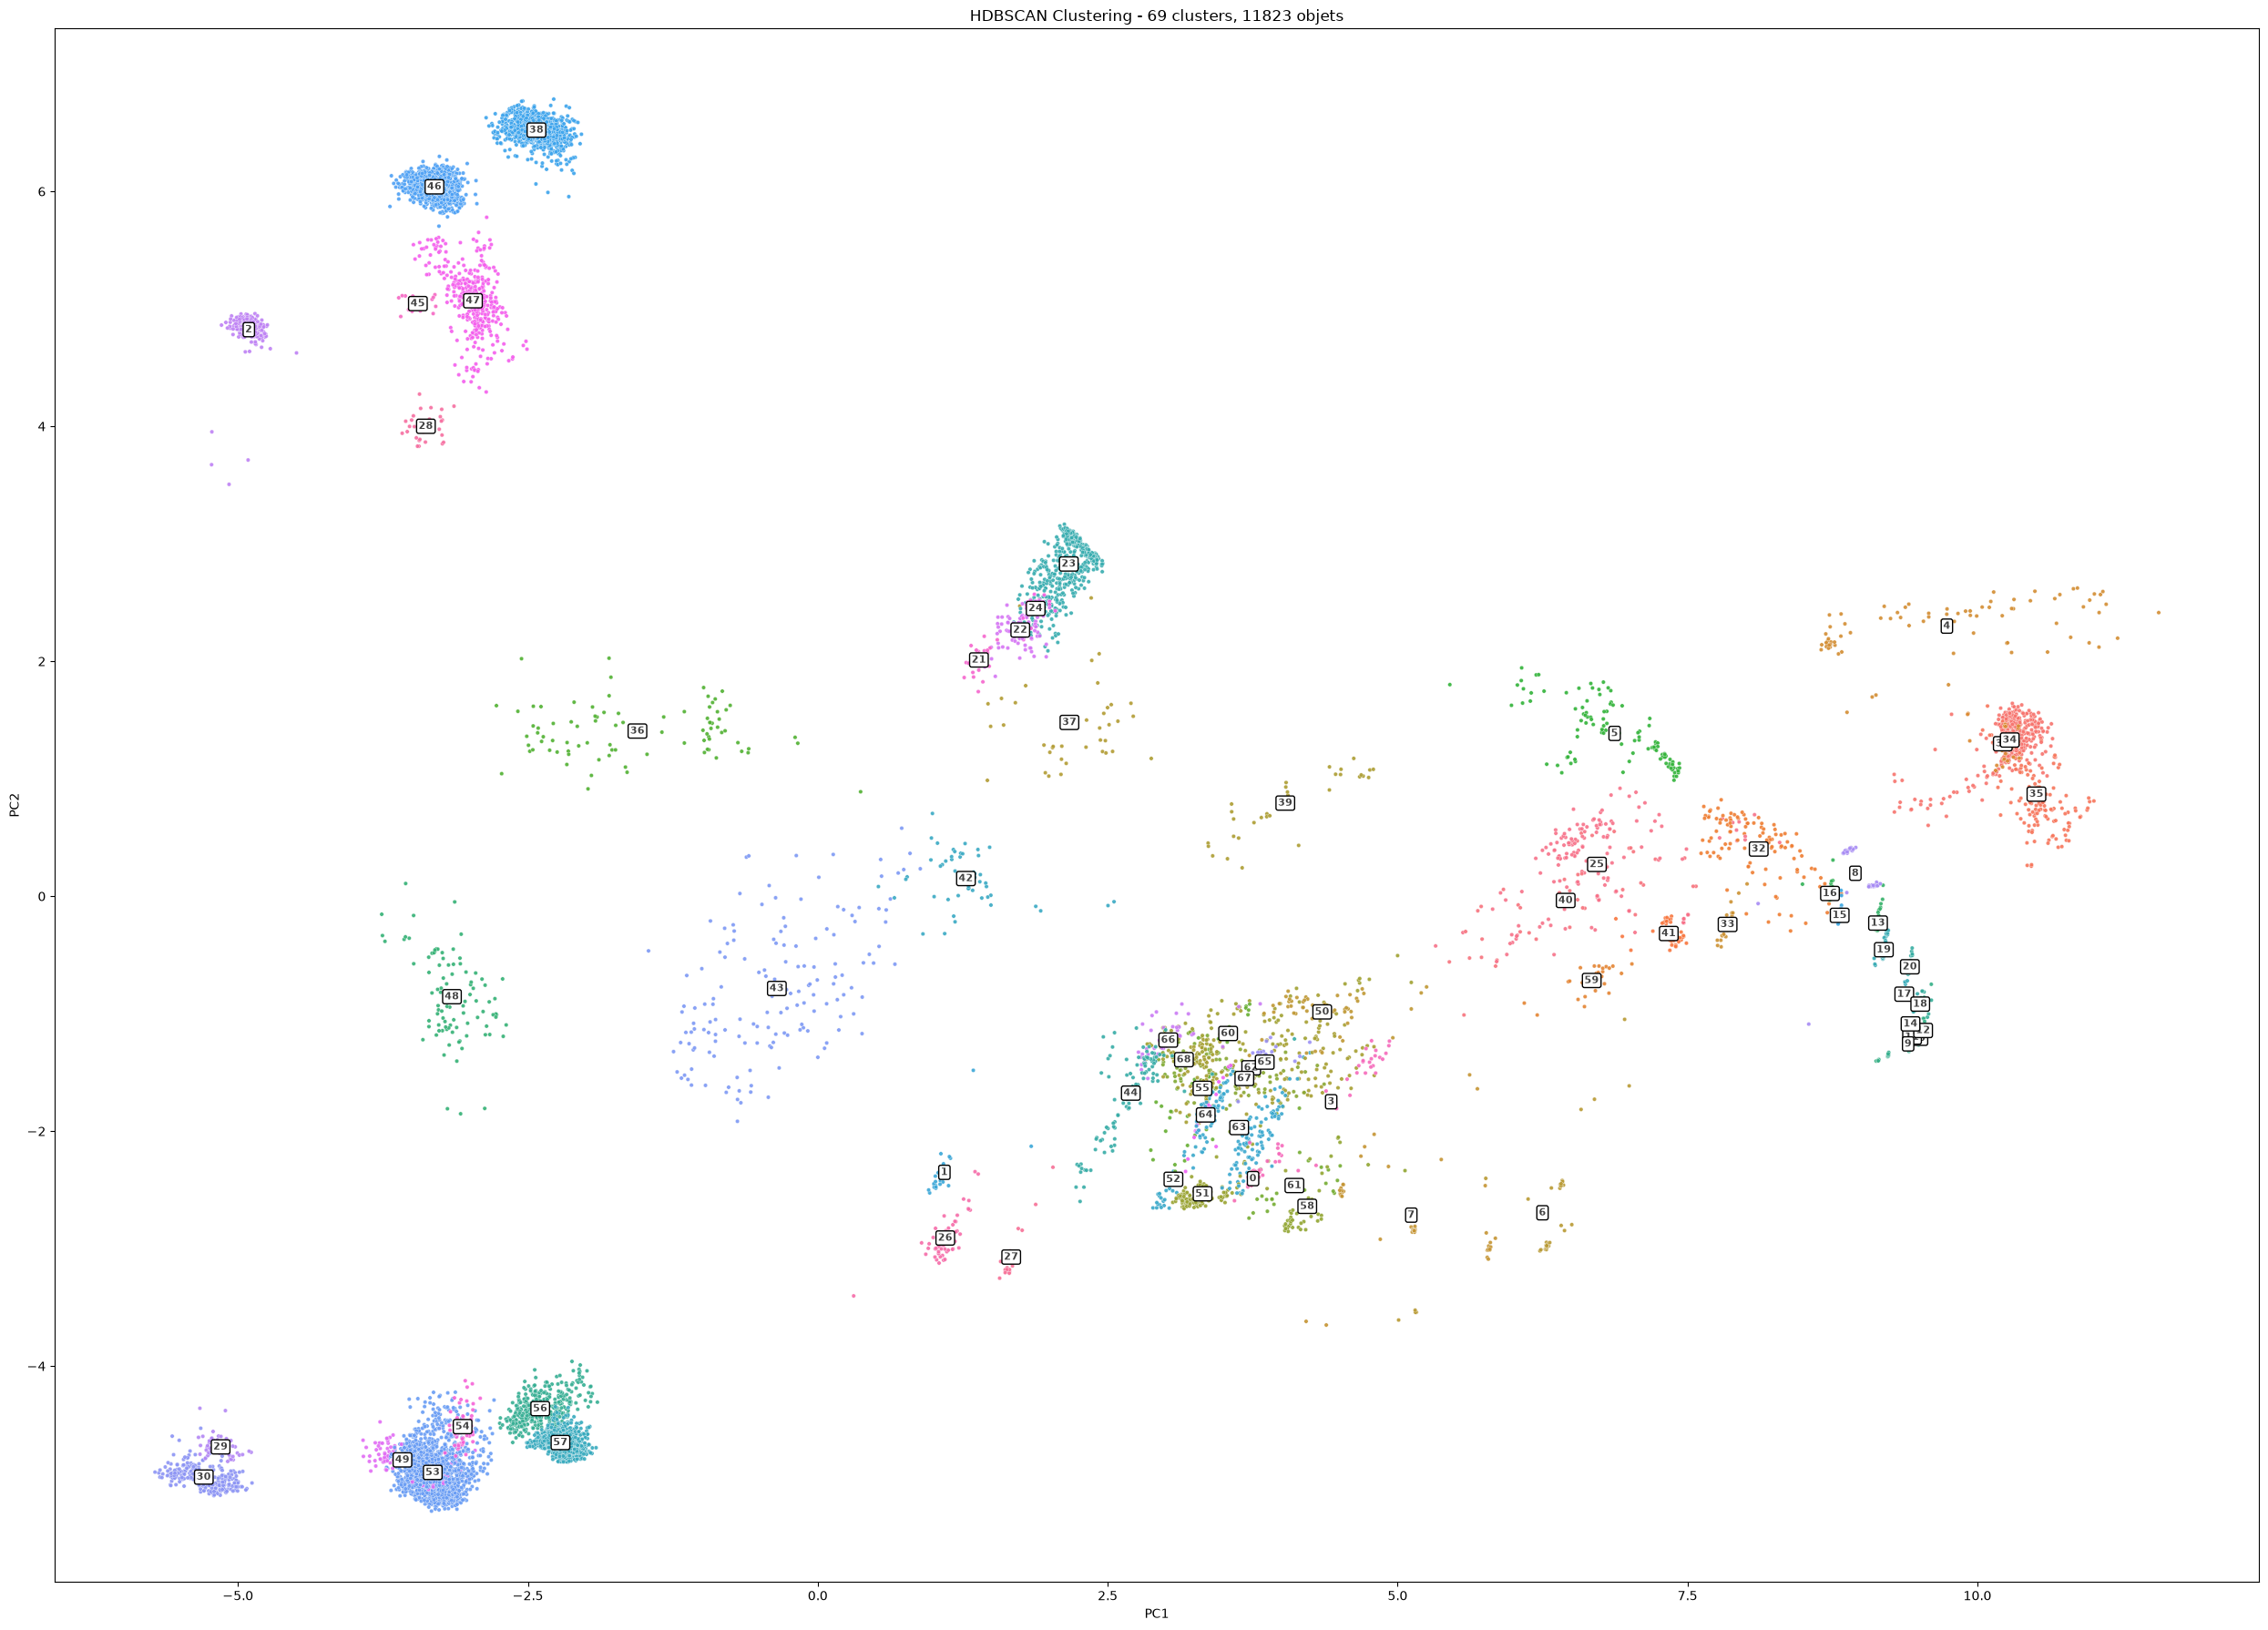

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## on retire les objets non clusterisés
mask = labels != -1
X_clean = X_scaled[mask]
labels_clean= labels[mask]
norad_clean = [norad_ids[i] for i in range(len(norad_ids)) if mask[i]]


def viz_3d_on_clusters(X, labels):
    """X is a (14 993, 64) ndarray of already scaled vectors, we reduce the dimension from 64 to 3 with principal components analysis, and show the clusters
    """
    pca = PCA(n_components=3)
    X_3d = pca.fit_transform(X)

    fig = plt.figure(figsize= (10,10))
    ax = fig.add_subplot(projection='3d')

    scatter = ax.scatter(X_3d[:,0], X_3d[:,1] , X_3d[:,2], c=labels, cmap='tab10', s=5, alpha=0.8)
    ax.legend(*scatter.legend_elements(), title='cluster')
    ax.view_init(elev=0, azim=110)

    plt.tight_layout()
    plt.show()

def viz_2d_on_clusters(X, labels, min_cluster_size = 20, min_samples=15):
    """X is a (14 993, 64) ndarray of already scaled vectors, we reduce the dimension from 64 to 2 with principal components analysis, and show the clusters
    """
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)
    df = pd.DataFrame({'x' : X_2d[:,0], 'y' : X_2d[:,1], 'cluster' : labels.astype(str)})

    fig, ax = plt.subplots(figsize=(25,18))

    sns.scatterplot(data=df , x='x',y='y',hue='cluster', palette='husl', s=10, alpha=0.9, legend=False, ax=ax)

    for cluster_id, group in df.groupby('cluster'):
        cx,cy = group['x'].mean(), group['y'].mean()
        ax.annotate(str(cluster_id), (cx,cy), fontsize=8, fontweight='bold', ha='center', va='center', bbox=dict(boxstyle='round,pad=0.2' , fc ='white', ec='black'), alpha = 0.75)

    ax.set_title(f"HDBSCAN Clustering - {len(set(labels))} clusters, {len(labels)} objets - min_cluster_size = {min_cluster_size}, min_samples = {min_samples}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    
    plt.tight_layout()
    plt.show()


viz_2d_on_clusters(X_clean, labels_clean)




In [95]:

## il s'avère que le cluster 38 est composé de Starlink 548xx à 587xx 
cluster_38 = [norad_ids[i] for i in range(len(norad_ids)) if labels[i] == 38]
X_cluster_38 = [X_scaled[i] for i in range(len(norad_ids)) if labels[i]  ==38]

cluster_38 = [norad_ids[i] for i in range(len(norad_ids)) if labels[i] == 38]
X_cluster_38 = [X_scaled[i] for i in range(len(norad_ids)) if labels[i]  ==38]
print(cluster_38)
print(len(cluster_38))

[54820, 54821, 54822, 54823, 54824, 54826, 54828, 54830, 54831, 54834, 54835, 54838, 54840, 54841, 54842, 54843, 54844, 54845, 54846, 54848, 54850, 54851, 54852, 54853, 54855, 54856, 54857, 54858, 54859, 54860, 54861, 54862, 54863, 54864, 54865, 54866, 54867, 54868, 54869, 54870, 54871, 54873, 55331, 55332, 55333, 55334, 55335, 55336, 55337, 55338, 55339, 55340, 55341, 55342, 55343, 55345, 55346, 55347, 55348, 55349, 55350, 55351, 55352, 55353, 55354, 55355, 55357, 55358, 55359, 55360, 55361, 55362, 55364, 55365, 55366, 55367, 55368, 55369, 55370, 55371, 55372, 55373, 55374, 55375, 55376, 55378, 55379, 55381, 55382, 55383, 55384, 55385, 55386, 55449, 55450, 55451, 55452, 55453, 55454, 55455, 55456, 55457, 55458, 55459, 55460, 55461, 55462, 55464, 55465, 55466, 55467, 55468, 55469, 55470, 55471, 55472, 55474, 55475, 55477, 55478, 55479, 55480, 55481, 55483, 55484, 55485, 55486, 55487, 55488, 55489, 55490, 55491, 55492, 55493, 55494, 55495, 55497, 55498, 55499, 55500, 55501, 55569, 55570

In [98]:
def create_cluster_csv(norad_ids, labels, name):
    # X est un vecteur de dim 64 représentant un unique satellite (moyenne des cls tokens des différentes fenêtres de l'objet)
    df = pd.DataFrame({
        'norad' : norad_ids, 'cluster' : labels
    })
    out_path = Path(base) / '..' / '..' / 'outputs' / 'clustering' / f'cluster_leo_{name}.csv'
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path , index=False)

create_cluster_csv(norad_ids, labels, 'all_dataset')

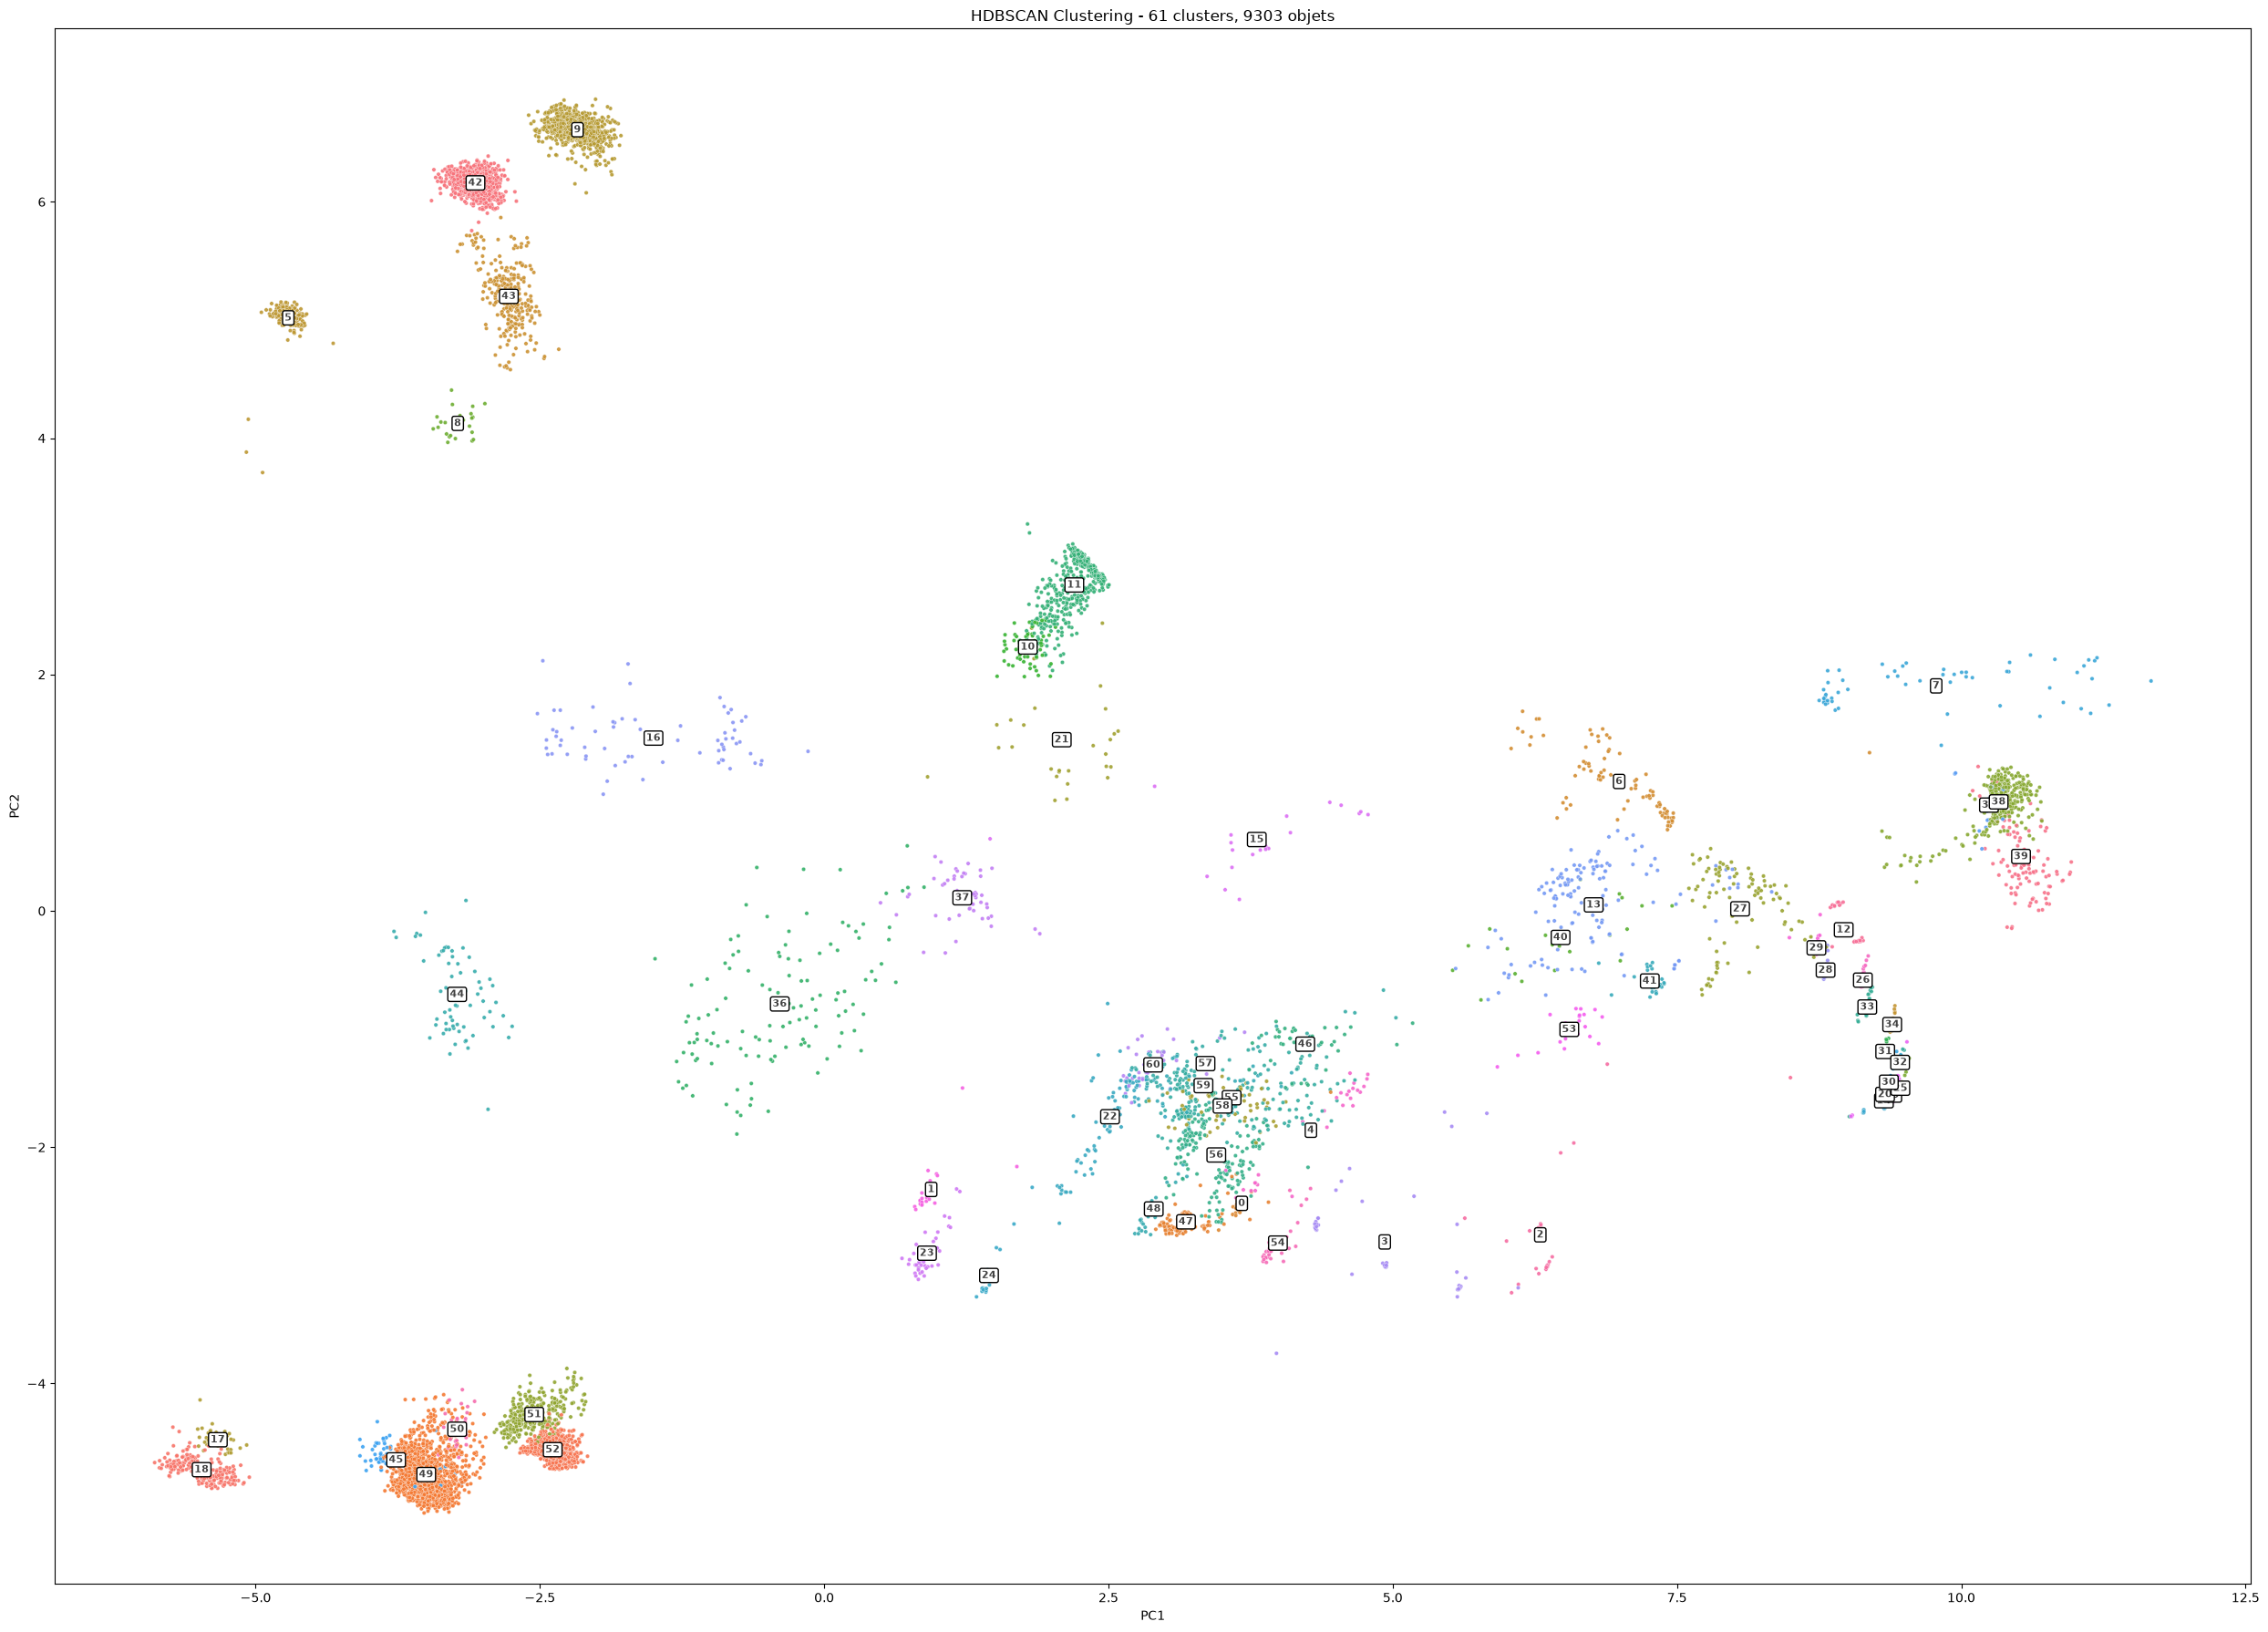

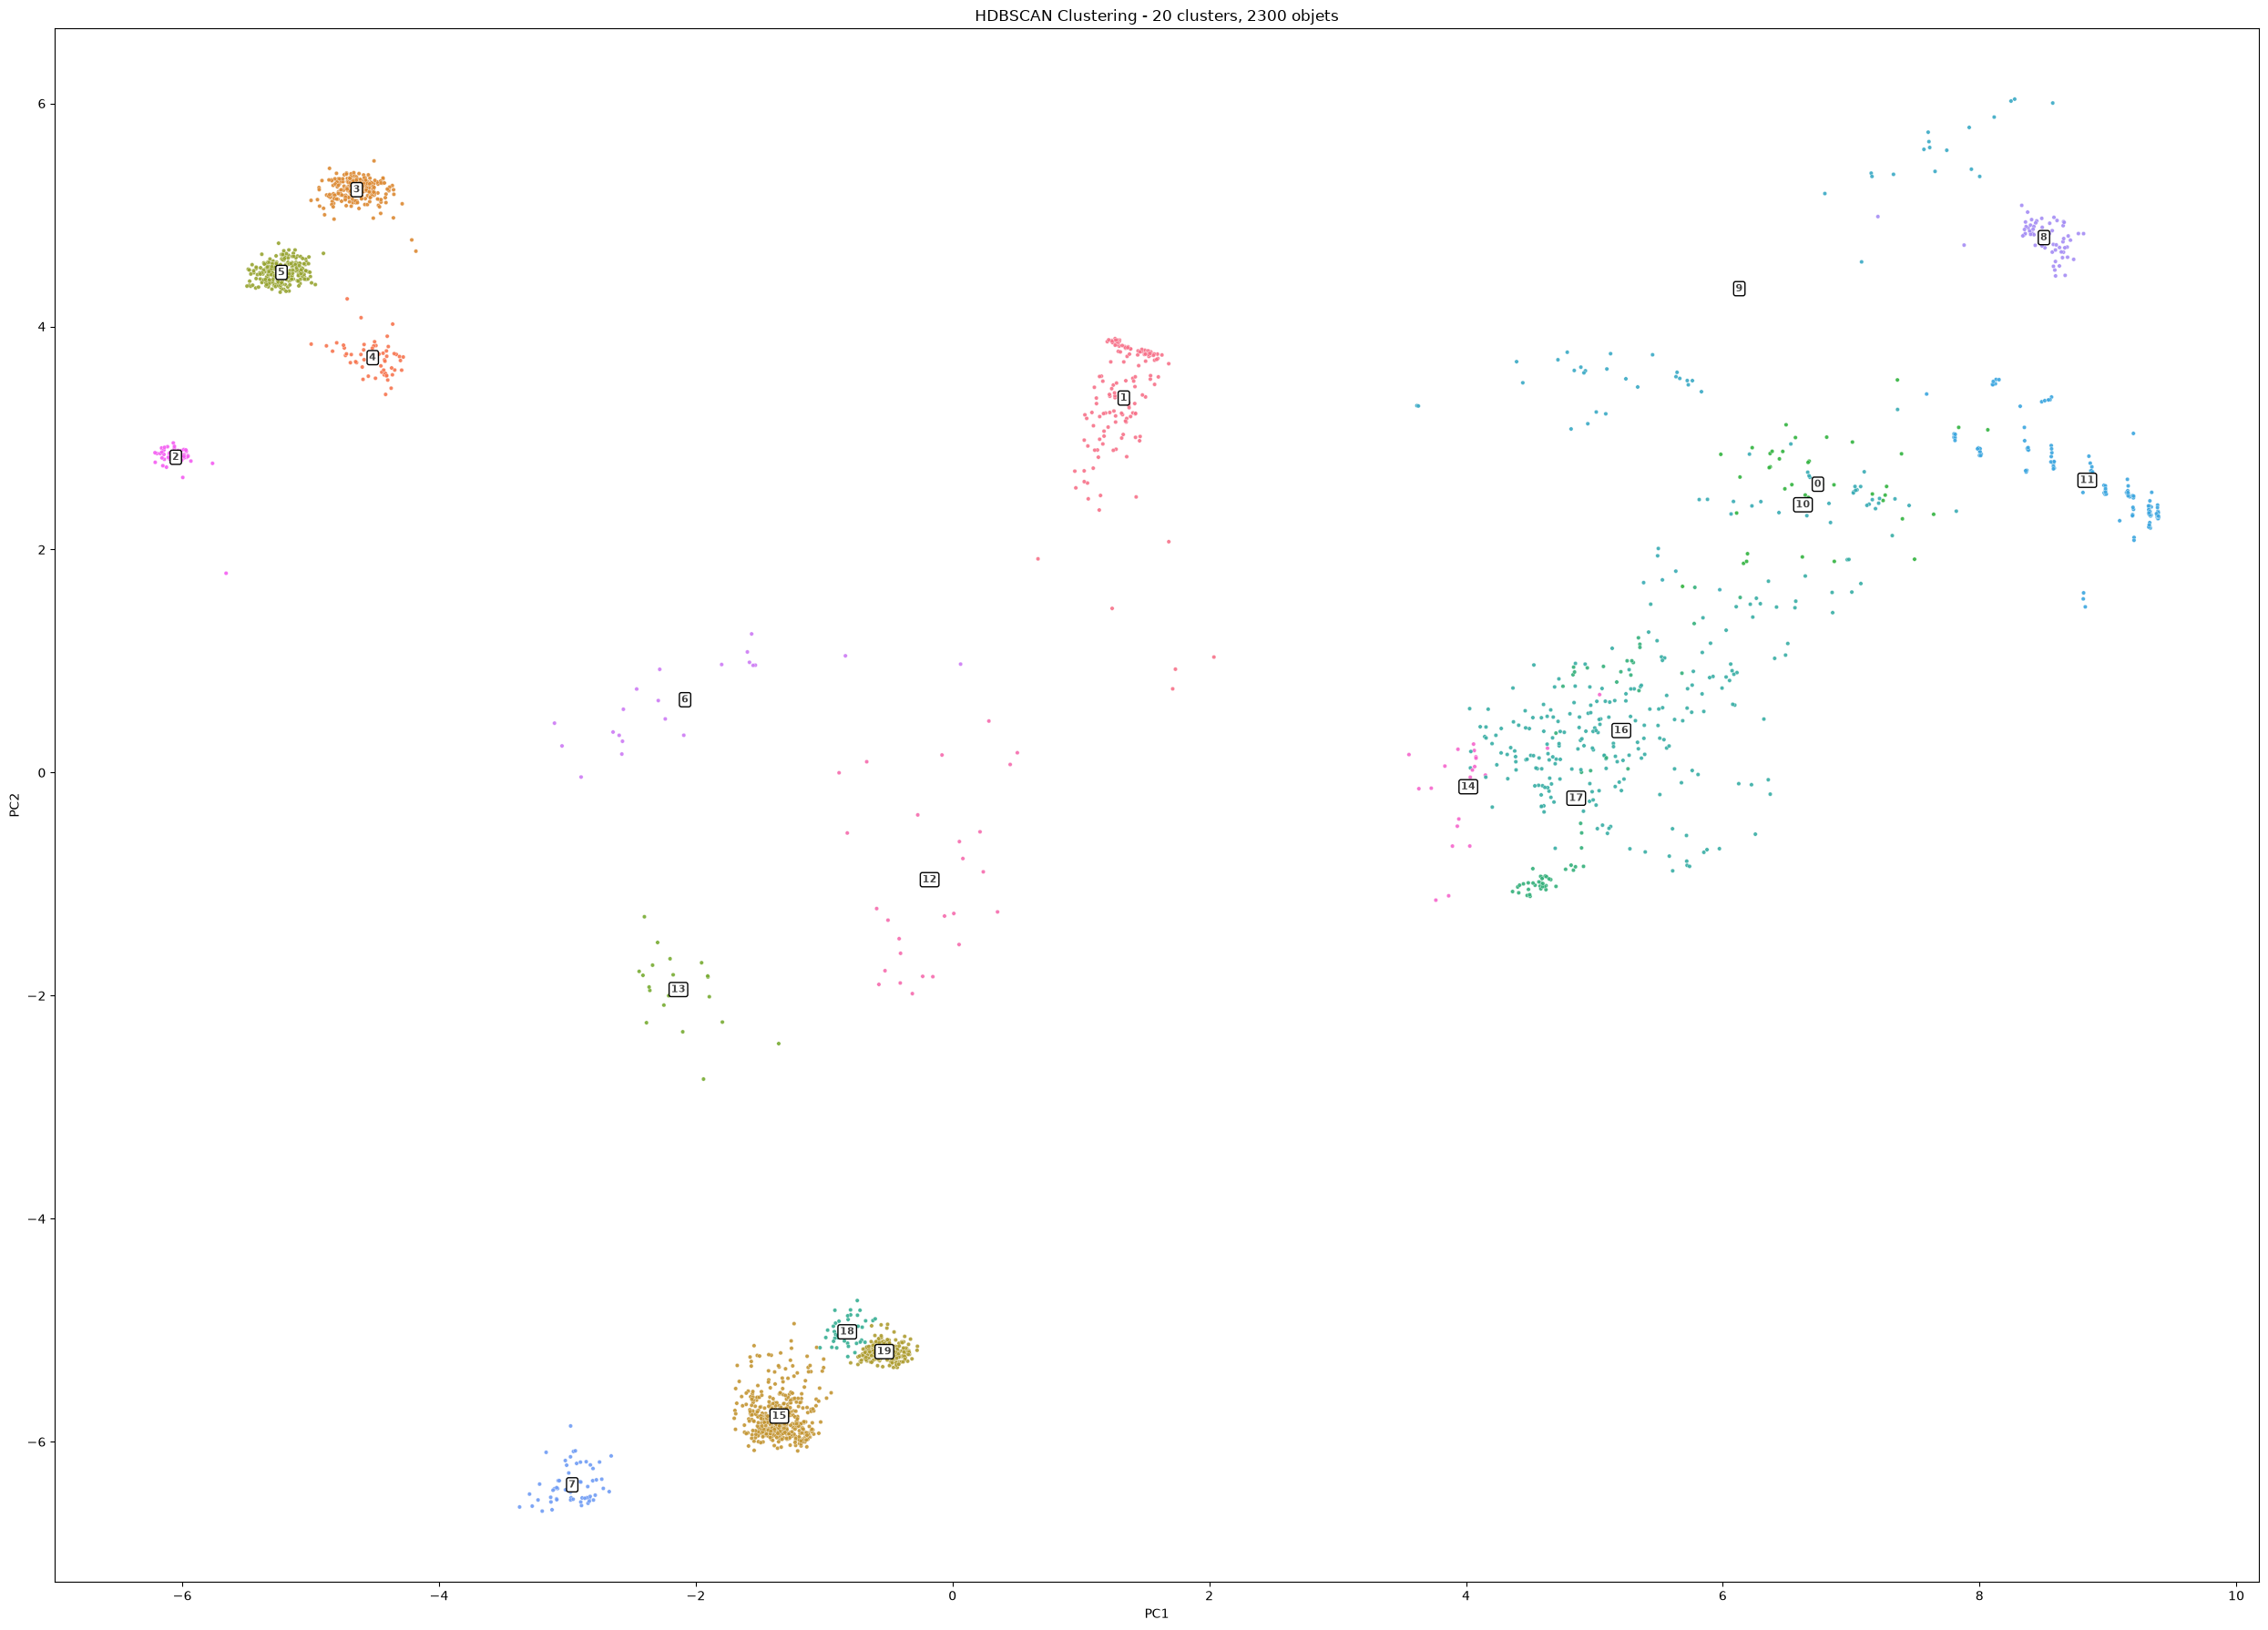

In [99]:
## on va maintenant tester la bonne généralisation du préentrainement en reproduisant le split train/val avec la seed de config

from ml.dataset import split_by_object

train_ids, val_ids = split_by_object(object_ids=norad_ids, val_split=0.2, seed=42)

X_obj_train = np.stack([out[n] for n in train_ids])
X_obj_val = np.stack([out[n] for n in val_ids])


X_scaled_train = StandardScaler().fit_transform(X_obj_train)
X_scaled_val = StandardScaler().fit_transform(X_obj_val)

labels_train = clusterer.fit_predict(X_scaled_train)
labels_val = clusterer.fit_predict(X_scaled_val)

mask_train = labels_train != -1
mask_val = labels_val != -1

X_scaled_train_clean = X_scaled_train[mask_train]
labels_train_clean = labels_train[mask_train]

X_scaled_val_clean = X_scaled_val[mask_val]
labels_val_clean = labels_val[mask_val]

viz_2d_on_clusters(X_scaled_train_clean, labels_train_clean)
viz_2d_on_clusters(X_scaled_val_clean, labels_val_clean)


In [102]:

norad_train_clean, norad_val_clean = [train_ids[i] for i in range(len(train_ids)) if mask_train[i]], [val_ids[i] for i in range(len(val_ids)) if mask_val[i]]
create_cluster_csv(norad_train_clean, labels_train_clean, 'train_norads')
create_cluster_csv(norad_val_clean, labels_val_clean, 'val_norads')

In [104]:
## on va tester différentes configuration de paramètres HDBSCAN

def hdbscan_params_cluster_test(X):
    for cluster_size in range(2,21,5) : 
        for samples in range(2,21, 5) : 
            clusterer = hdbscan.HDBSCAN(min_cluster_size=cluster_size, min_samples=samples)
            labels = clusterer.fit_predict(X)
            mask = labels !=-1

            X_clean = X[mask]
            labels_clean = labels[mask]

            viz_2d_on_clusters(X_clean, labels_clean, min_cluster_size=cluster_size, min_samples=samples)

hdbscan_params_cluster_test(X_scaled)


TypeError: viz_2d_on_clusters() got an unexpected keyword argument 'min_cluster_size'